In [65]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [66]:
import logging

logger = logging.getLogger(__name__)

# Configure root logger once:
logging.basicConfig(
    level=logging.DEBUG,                            # show DEBUG+ messages
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

In [67]:
N = 3
cycles = 1
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [0.1]*N
no_occurrences_sds = [0]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Period standard deviations: [0.1, 0.1, 0.1]
Number of occurrences standard deviations: [0, 0, 0]


In [68]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals)
        
        
    def sample_noise (self, i):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        sample = int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))
        return sample


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        sample = np.random.normal(loc=1, scale=0)
        return .5 if sample <= .5 else sample

In [69]:
etg = ExampleETG(occurrences, time_intervals, noise_sds, no_occurrences_sds)
ess = ExampleSampleSpace()

2025-07-31 15:57:02,846 utils DEBUG: Checks if constraint is satisfied with value: 1
2025-07-31 15:57:02,846 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,847 utils DEBUG: Checks if constraint is satisfied with value: 2
2025-07-31 15:57:02,847 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,847 utils DEBUG: Checks if constraint is satisfied with value: 3
2025-07-31 15:57:02,848 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,848 TimeSeriesGeneratorV2 DEBUG: new occurrences: [1, 2, 3]
2025-07-31 15:57:02,848 TimeSeriesGeneratorV2 DEBUG: new spacings: [0.5, 0.3333333333333333, 0.25]


In [70]:
def on_event(event):
    logger.info(f"event: {event}")
    logger.info("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(cycles*N, 10)
logger.info(f"Generated data: {data}")

2025-07-31 15:57:02,855 utils DEBUG: Checks if constraint is satisfied with value: 0.5899135738209944
2025-07-31 15:57:02,855 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,855 TimeSeriesGeneratorV2 DEBUG: Waiting 0.5899016528920393 seconds.
2025-07-31 15:57:02,914 utils DEBUG: Checks if constraint is satisfied with value: 1.0
2025-07-31 15:57:02,915 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,915 __main__ INFO: event: (0.5899135738209944, 1.0)
2025-07-31 15:57:02,915 __main__ INFO: --------
2025-07-31 15:57:02,916 utils DEBUG: Checks if constraint is satisfied with value: 1.3540057226992288
2025-07-31 15:57:02,916 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,916 TimeSeriesGeneratorV2 DEBUG: Waiting 0.743678002057139 seconds.
2025-07-31 15:57:02,991 utils DEBUG: Checks if constraint is satisfied with value: 1.0
2025-07-31 15:57:02,991 utils DEBUG: Constraint satisfied
2025-07-31 15:57:02,992 __main__ INFO: event: (1.3540057226992288, 1.0)
2025-07-31 15:57:02,9

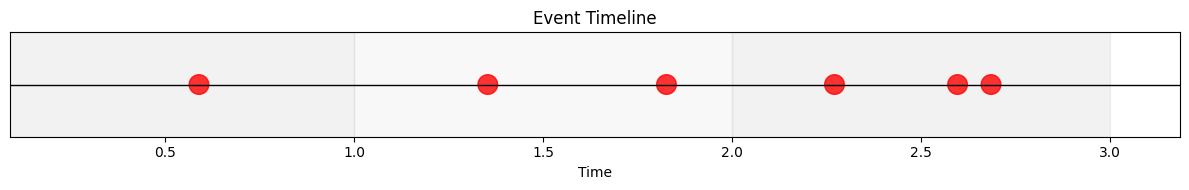

In [71]:
from Analytics import plot_timeline, extend_intervals
plot_timeline(data, extend_intervals(time_intervals, cycles))


In [72]:
from Analytics import count_number_of_occurrences_in_intervals
count_number_of_occurrences_in_intervals(extend_intervals(time_intervals, cycles), data)

[1, 2, 3]